### Librerías

In [ ]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid, cross_val_score, train_test_split, learning_curve
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

## Carga datos

### Obtener datos (solo una vez)

In [ ]:
#Obtención de la data (hacerlo solo una vez si no está la carpeta)
from LHC import experiment_CMS
experiment_CMS(num_img=500, size=64, zip_name="CERN_dataset")

Dataset generado con 500 imágenes por clase.
Archivo comprimido: CERN_dataset.zip


### Cargar datos (cada vez que se reinicia el kernel)

In [45]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

def cargar_datos(zip_path="CERN_dataset.zip", carpeta_salida="CERN_datos", num_por_carpeta=500):
    #1. Proceso para descomprimir el archivo ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(carpeta_salida)
    X = []
    y = []
    #2. Recorrer las carpetas con las imagenes
    for clase in os.listdir(carpeta_salida):
        clase_path = os.path.join(carpeta_salida, clase)
        if os.path.isdir(clase_path):
            img_names = os.listdir(clase_path)
            if num_por_carpeta is not None:
                img_names = img_names[:num_por_carpeta]
            for img_name in tqdm(img_names, desc=f"Cargando {clase}"):
                img_path = os.path.join(clase_path, img_name)

                # 3. Procedimiento para cargar imagenes en escala de grises
                img = Image.open(img_path).convert("L")
                X.append(np.array(img))
                y.append(clase)  # etiqueta = nombre de la carpeta

    X = np.array(X)
    return X, y

X, y = cargar_datos("CERN_dataset.zip")
print(f"Se cargaron {len(X)} imágenes.")
print(f"Clases encontradas: {set(y)}")
print("Dimensiones de las imágenes:", X.shape)

Cargando electron:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando muon:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando neutrino:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando proton:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando quark:   0%|          | 0/500 [00:00<?, ?it/s]

Cargando tau:   0%|          | 0/500 [00:00<?, ?it/s]

Se cargaron 3000 imágenes.
Clases encontradas: {'quark', 'tau', 'electron', 'muon', 'proton', 'neutrino'}
Dimensiones de las imágenes: (3000, 64, 64)


### Pre procesamiento datos

In [40]:
# Pre-procesamiento para clasificación

print('Shape original:', X.shape)
# 2. Aplanar imágenes
X_flat = X.reshape(X.shape[0], -1)
print('Shape aplanado:', X_flat.shape)

Shape original: (3000, 64, 64)
Shape aplanado: (3000, 4096)


Shape escalado: (3000, 4096)


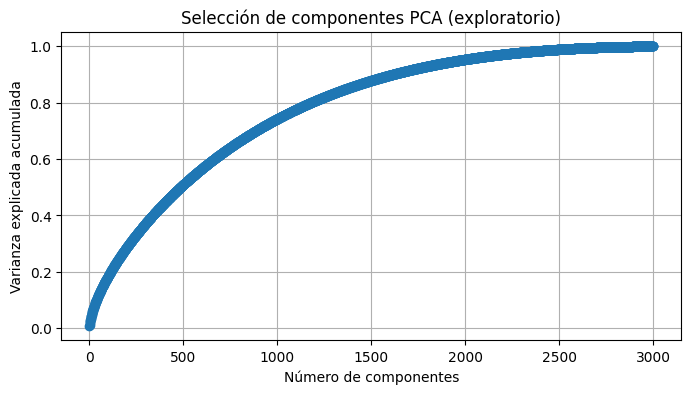

Número óptimo de componentes PCA para >=95% varianza (exploratorio): 1970


In [41]:
# Selección óptima de componentes PCA según varianza explicada acumulada (solo exploratorio, sin leakage)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

# Solo para análisis exploratorio, no para alimentar el modelo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
print('Shape escalado:', X_scaled.shape)

pca_full = PCA()
pca_full.fit(X_scaled)

cumsum = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(8,4))
plt.plot(cumsum, marker='o')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Selección de componentes PCA (exploratorio)')
plt.grid(True)
plt.show()

n_opt = np.argmax(cumsum >= 0.95) + 1
print(f'Número óptimo de componentes PCA para >=95% varianza (exploratorio):', n_opt)

### Regresión logística 

In [48]:
# Pipeline + búsqueda de hiperparámetros + validación cruzada para regresión logística SOLO con penalización L2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import ParameterGrid, cross_val_score
from tqdm.notebook import tqdm

pipe_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Retiene 95% de varianza
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

param_grid_logreg = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l2'],
    'clf__solver': ['saga']
}

In [49]:
grid = list(ParameterGrid(param_grid_logreg))
results = []

for params in tqdm(grid, desc="GridSearch LogReg"):
    pipe_logreg.set_params(**params)
    try:
        scores = cross_val_score(pipe_logreg, X_flat, y, cv=5, scoring='accuracy', n_jobs=-1)
        results.append((params, scores.mean()))
    except Exception as e:
        print(f"Error con parámetros {params}: {e}")

best_params, best_score = max(results, key=lambda x: x[1])
print('Mejores parámetros LogReg:', best_params)
print('Mejor score LogReg:', best_score)

GridSearch LogReg:   0%|          | 0/4 [00:00<?, ?it/s]

Mejores parámetros LogReg: {'clf__C': 0.01, 'clf__penalty': 'l2', 'clf__solver': 'saga'}
Mejor score LogReg: 0.536


In [50]:
# Entrenamiento y evaluación final Regresión Logística 

# Usa los mejores parámetros encontrados
pipe_logreg_best = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', LogisticRegression(max_iter=1000, random_state=42, C=best_params['clf__C'], penalty=best_params['clf__penalty'], solver=best_params['clf__solver'] + (', l1_ratio=best_params["clf__l1_ratio"]' if 'clf__l1_ratio' in best_params else '')))
])

# Divide los datos
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento
pipe_logreg_best.fit(X_train, y_train)

# Evaluación
score_test = pipe_logreg_best.score(X_test, y_test)
print(f'Accuracy LogReg en test: {score_test:.4f}')

Accuracy LogReg en test: 0.5483


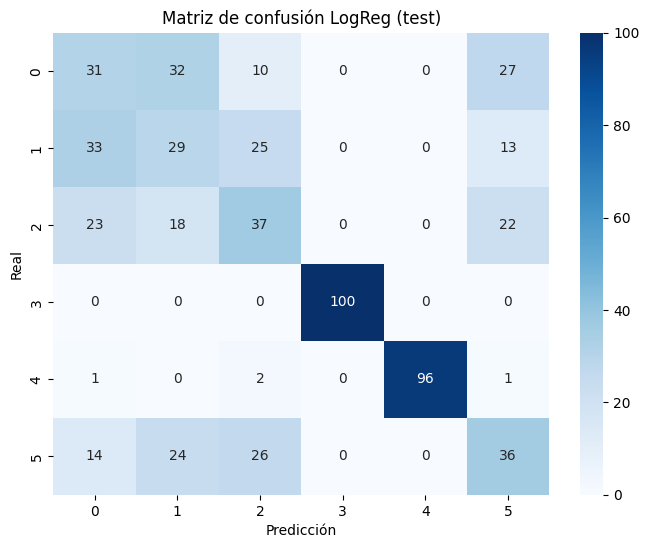

--- Métricas LogReg (train) ---
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
--- Métricas LogReg (test) ---
Accuracy: 0.5483333333333333
Precision: 0.5531852217203446
Recall: 0.5483333333333333
F1: 0.5506743101240694

Reporte de clasificación:
              precision    recall  f1-score   support

    electron       0.30      0.31      0.31       100
        muon       0.28      0.29      0.29       100
    neutrino       0.37      0.37      0.37       100
      proton       1.00      1.00      1.00       100
       quark       1.00      0.96      0.98       100
         tau       0.36      0.36      0.36       100

    accuracy                           0.55       600
   macro avg       0.55      0.55      0.55       600
weighted avg       0.55      0.55      0.55       600



c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\laura\REPOSITORIOS\mineria-de

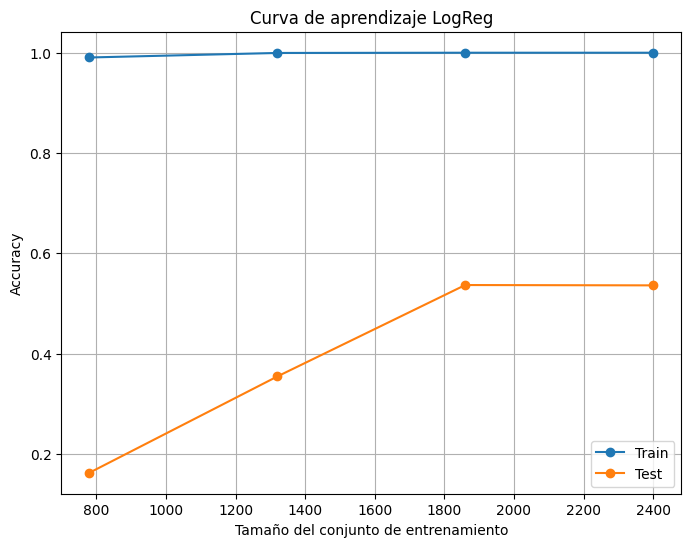

In [ ]:
# Métricas y visualización para Regresión Logística
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

# Predicciones
y_pred_train = pipe_logreg_best.predict(X_train)
y_pred_test = pipe_logreg_best.predict(X_test)

# Obtener nombres de clases
class_names = sorted(list(set(y)))

# Matriz de confusión con nombres de clases
cm = confusion_matrix(y_test, y_pred_test, labels=class_names)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de confusión LogReg (test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Métricas de train
print('--- Métricas LogReg (train) ---')
print('Accuracy:', accuracy_score(y_train, y_pred_train))
print('Precision:', precision_score(y_train, y_pred_train, average='weighted', zero_division=0))
print('Recall:', recall_score(y_train, y_pred_train, average='weighted', zero_division=0))
print('F1:', f1_score(y_train, y_pred_train, average='weighted', zero_division=0))

# Métricas de test
print('--- Métricas LogReg (test) ---')
print('Accuracy:', accuracy_score(y_test, y_pred_test))
print('Precision:', precision_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('Recall:', recall_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('F1:', f1_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_test, target_names=class_names, zero_division=0))

# Curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(pipe_logreg_best, X_flat, y, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Train')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Test')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje LogReg')
plt.legend()
plt.grid(True)
plt.show()

In [54]:
# Curvas ROC para Regresión Logística (multiclase OneVsRest)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier

# Binarizar las etiquetas para ROC multicategoría
y_test_bin = label_binarize(y_test, classes=class_names)
n_classes = y_test_bin.shape[1]

# Entrenar modelo OneVsRest
ovr_clf = OneVsRestClassifier(pipe_logreg_best.named_steps['clf'])
ovr_clf.fit(X_train, label_binarize(y_train, classes=class_names))
y_score = ovr_clf.decision_function(X_test)

# Calcular curvas ROC y AUC para cada clase
plt.figure(figsize=(10,8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Clase {class_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curvas ROC Regresión Logística (multiclase)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

NameError: name 'class_names' is not defined

### SVM

In [51]:
# Pipeline + búsqueda de hiperparámetros + validación cruzada para SVM con barra de progreso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.model_selection import ParameterGrid, cross_val_score
from tqdm.notebook import tqdm

pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # Retiene 95% de varianza
    ('clf', SVC(kernel='rbf', random_state=42))
])

param_grid_svm = {
    'clf__C': [0.1, 1, 10],
    'clf__gamma': ['scale', 0.01, 0.1, 1]
}

grid = list(ParameterGrid(param_grid_svm))
results = []

for params in tqdm(grid, desc="GridSearch SVM"):
    pipe_svm.set_params(**params)
    scores = cross_val_score(pipe_svm, X_flat, y, cv=5, scoring='accuracy', n_jobs=-1)
    results.append((params, scores.mean()))

best_params, best_score = max(results, key=lambda x: x[1])
print('Mejores parámetros SVM:', best_params)
print('Mejor score SVM:', best_score)

GridSearch SVM:   0%|          | 0/12 [00:00<?, ?it/s]

Mejores parámetros SVM: {'clf__C': 10, 'clf__gamma': 'scale'}
Mejor score SVM: 0.35300000000000004


In [52]:
# Entrenamiento y evaluación final SVM

# Usa los mejores parámetros encontrados
pipe_svm_best = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),
    ('clf', SVC(kernel='rbf', random_state=42, C=best_params['clf__C'], gamma=best_params['clf__gamma']))
])

# Divide los datos
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, test_size=0.2, random_state=42, stratify=y)

# Entrenamiento
pipe_svm_best.fit(X_train, y_train)

# Evaluación
score_test = pipe_svm_best.score(X_test, y_test)
print(f'Accuracy SVM en test: {score_test:.4f}')

Accuracy SVM en test: 0.3483


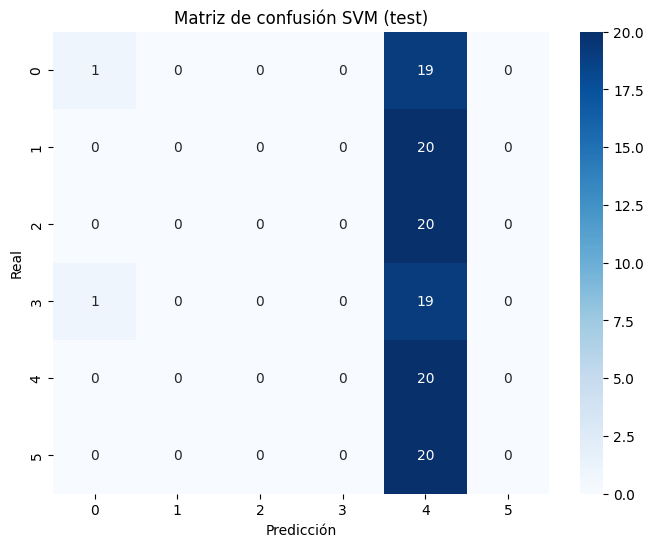

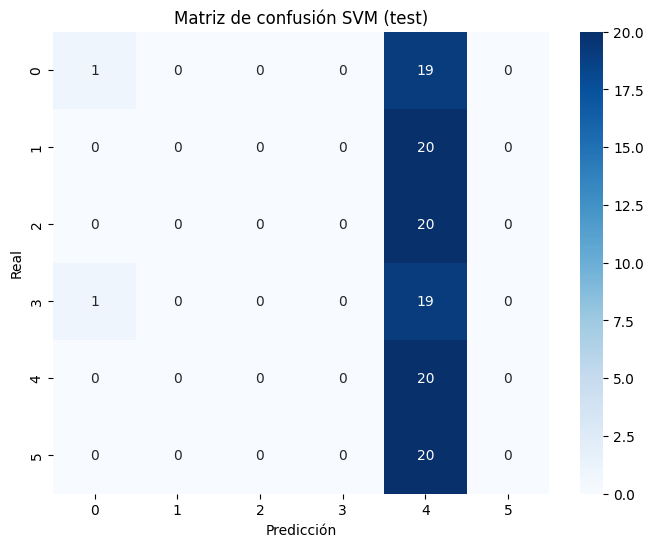

--- Métricas SVM (train) ---
Accuracy: 0.8291666666666667
Precision: 0.867468254126631
Recall: 0.8291666666666667
F1: 0.829998704574572
--- Métricas SVM (test) ---
Accuracy: 0.175
Precision: 0.1115819209039548
Recall: 0.175
F1: 0.06346069389547651

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.50      0.05      0.09        20
           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00        20
           4       0.17      1.00      0.29        20
           5       0.00      0.00      0.00        20

    accuracy                           0.17       120
   macro avg       0.11      0.18      0.06       120
weighted avg       0.11      0.17      0.06       120



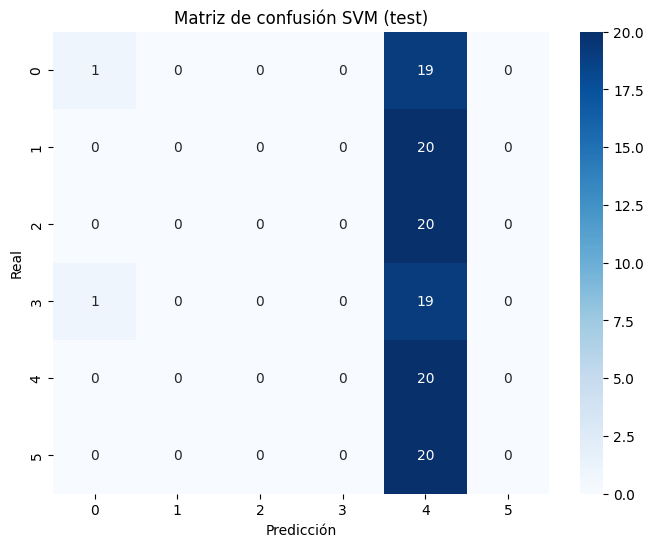

--- Métricas SVM (train) ---
Accuracy: 0.8291666666666667
Precision: 0.867468254126631
Recall: 0.8291666666666667
F1: 0.829998704574572
--- Métricas SVM (test) ---
Accuracy: 0.175
Precision: 0.1115819209039548
Recall: 0.175
F1: 0.06346069389547651

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.50      0.05      0.09        20
           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00        20
           4       0.17      1.00      0.29        20
           5       0.00      0.00      0.00        20

    accuracy                           0.17       120
   macro avg       0.11      0.18      0.06       120
weighted avg       0.11      0.17      0.06       120



c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\laura\REPOSITORIOS\mineria-de

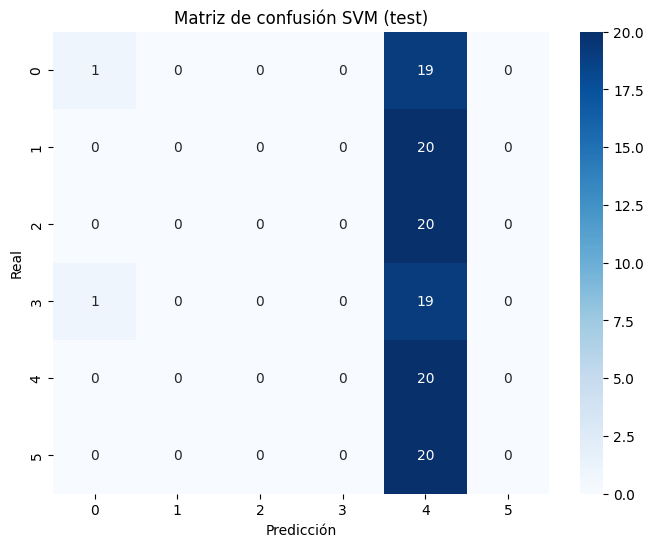

--- Métricas SVM (train) ---
Accuracy: 0.8291666666666667
Precision: 0.867468254126631
Recall: 0.8291666666666667
F1: 0.829998704574572
--- Métricas SVM (test) ---
Accuracy: 0.175
Precision: 0.1115819209039548
Recall: 0.175
F1: 0.06346069389547651

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.50      0.05      0.09        20
           1       0.00      0.00      0.00        20
           2       0.00      0.00      0.00        20
           3       0.00      0.00      0.00        20
           4       0.17      1.00      0.29        20
           5       0.00      0.00      0.00        20

    accuracy                           0.17       120
   macro avg       0.11      0.18      0.06       120
weighted avg       0.11      0.17      0.06       120



c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
5 fits failed out of a total of 25.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\laura\REPOSITORIOS\mineria-de-datos\venv\Lib\site-packages\sklearn\base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\laura\REPOSITORIOS\mineria-de

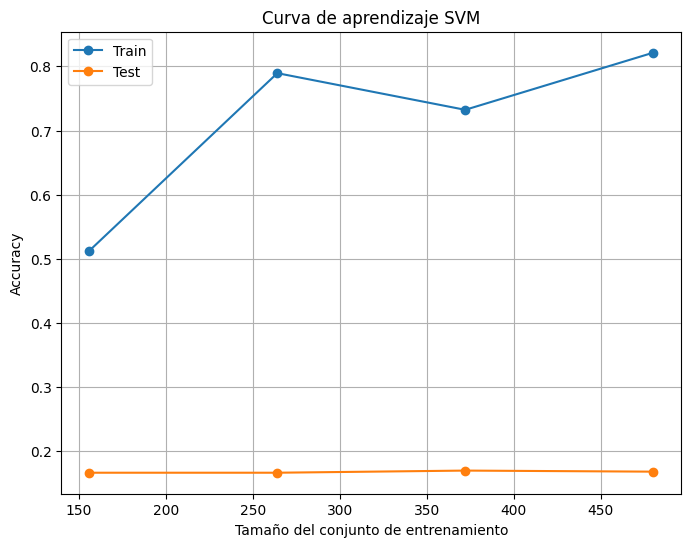

In [28]:
# Métricas y visualización para SVM
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

# Predicciones
y_pred_train = pipe_svm_best.predict(X_train)
y_pred_test = pipe_svm_best.predict(X_test)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de confusión SVM (test)')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

# Métricas de train
print('--- Métricas SVM (train) ---')
print('Accuracy:', accuracy_score(y_train, y_pred_train))
print('Precision:', precision_score(y_train, y_pred_train, average='weighted', zero_division=0))
print('Recall:', recall_score(y_train, y_pred_train, average='weighted', zero_division=0))
print('F1:', f1_score(y_train, y_pred_train, average='weighted', zero_division=0))

# Métricas de test
print('--- Métricas SVM (test) ---')
print('Accuracy:', accuracy_score(y_test, y_pred_test))
print('Precision:', precision_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('Recall:', recall_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('F1:', f1_score(y_test, y_pred_test, average='weighted', zero_division=0))
print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_test, zero_division=0))

# Curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(pipe_svm_best, X_flat, y_encoded, cv=5, scoring='accuracy', n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5))
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Train')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Test')
plt.xlabel('Tamaño del conjunto de entrenamiento')
plt.ylabel('Accuracy')
plt.title('Curva de aprendizaje SVM')
plt.legend()
plt.grid(True)
plt.show()